
# Avalanche: RRR vs Baseline on SplitCIFAR10

This notebook reproduces your script in a notebook-friendly way and adds a **baseline** run with no continual-learning plugin for comparison.

**What it does**
- Builds a 5-experience SplitCIFAR10 benchmark
- Trains a baseline `Naive` strategy (no plugins)
- Trains `Naive` again but with your `RRRPlugin` added
- Logs accuracy & loss at experience and stream level

> Tip: run this in your Docker/DevContainer so dependencies and GPUs are correctly used.



## 1. Imports & Setup
- We add the parent directory of this notebook (`src/`) to `sys.path` so `from plugins import RRRPlugin` works when the notebook sits in `src/examples/`.
- We set a random seed for reproducibility.


In [27]:

import os
import sys
import random
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

# If this notebook lives in repo/src/examples, this puts repo/src on sys.path
nb_dir = Path.cwd()
src_dir = nb_dir.parent
if src_dir.exists():
    sys.path.insert(0, str(src_dir))

import torch
import torchvision

from avalanche.benchmarks.classic import SplitCIFAR10
from avalanche.training.supervised import Naive
from avalanche.training.plugins import EvaluationPlugin
from avalanche.logging import InteractiveLogger
from avalanche.evaluation.metrics import accuracy_metrics, loss_metrics

from plugins import RRRPlugin

# Reproducibility
SEED = int(os.environ.get("SEED", "123"))
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')


## 2. Build the SplitCIFAR10 benchmark
Avalanche already contains common CL benchmarks, such as Split-MNIST and Split-CIFAR10.
Check out Avalanche documentation at https://avalanche-api.continualai.org/en/v0.6.0/benchmarks.html to check out all available benchmarks.

In [3]:

# 5 experiences on CIFAR10
benchmark = SplitCIFAR10(n_experiences=5)
benchmark


100%|██████████| 170498071/170498071 [00:41<00:00, 4060941.51it/s]


Extracting /root/.avalanche/data/cifar10/cifar-10-python.tar.gz to /root/.avalanche/data/cifar10
Files already downloaded and verified



## 3. Model factory

We use `resnet18` with `num_classes=10`. Any PyTorch model can be used with Avalanche.


In [4]:

def build_model(num_classes=10):
    model = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    return model.to(device)



## 4. Evaluation plugin

Log accuracy and loss at both experience and stream level.


In [5]:

def build_eval_plugin():
    logger = InteractiveLogger()
    eval_plugin = EvaluationPlugin(
        accuracy_metrics(experience=True, stream=True),
        loss_metrics(experience=True, stream=True),
        loggers=[logger],
    )
    return eval_plugin



## 5. Strategy builders

- **Baseline**: `Naive` with no plugins.

- **RRR**: `Naive` with your `RRRPlugin` and given parameters.


In [11]:

def build_baseline_strategy():
    model = build_model(num_classes=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()
    eval_plugin = build_eval_plugin()
    strategy = Naive(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_mb_size=32,
        train_epochs=10,
        eval_mb_size=32,
        plugins=[],  # baseline: NO plugins
        evaluator=eval_plugin,
        device=device,
    )
    return strategy

def build_rrr_strategy(num_experiences):
    model = build_model(num_classes=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()
    eval_plugin = build_eval_plugin()

    rrr_parameters = {
        'xai_loss': torch.nn.L1Loss(),
        'xai_optimizer': torch.optim.Adam(model.parameters(), lr=0.0005),
        'xai_regularizer': 100.0,
        'mem_size': 1000,
        'mem_adaptive_size': True,
        'num_experiences': num_experiences,
        'batch_size': 32,
        'batch_size_mem': 32,
    }

    strategy = Naive(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_mb_size=32,
        train_epochs=10,
        eval_mb_size=32,
        plugins=[RRRPlugin(**rrr_parameters)],
        evaluator=eval_plugin,
        device=device,
    )
    return strategy



## 6. Train/Eval helpers


In [31]:

from typing import Dict, Any, List

def run_strategy(name: str, strategy: Naive, benchmark) -> Dict[str, Any]:
    print(f"\n===== Training: {name} =====")
    results = []
    for exp_id, experience in enumerate(benchmark.train_stream):
        print(f"\n--- Experience {experience.current_experience + 1}/{benchmark.n_experiences} ---")
        strategy.train(experience)
        print("\nEvaluating on test stream...")
        results.append(strategy.eval(benchmark.test_stream))
    return results


In [8]:
all_results: Dict[str, List[Any]] = {}


## 7. Run Baseline (no plugins)


In [38]:

baseline = build_baseline_strategy()
all_results['Baseline'] = run_strategy("Baseline", baseline, benchmark)
all_results['Baseline']


===== Training: Baseline =====

--- Experience 1/5 ---
-- >> Start of training phase << --
100%|██████████| 313/313 [00:03<00:00, 96.38it/s] 
Epoch 0 ended.
100%|██████████| 313/313 [00:03<00:00, 94.88it/s] 
Epoch 1 ended.
100%|██████████| 313/313 [00:03<00:00, 91.61it/s] 
Epoch 2 ended.
100%|██████████| 313/313 [00:03<00:00, 93.47it/s] 
Epoch 3 ended.
100%|██████████| 313/313 [00:03<00:00, 98.42it/s] 
Epoch 4 ended.
100%|██████████| 313/313 [00:03<00:00, 91.49it/s] 
Epoch 5 ended.
100%|██████████| 313/313 [00:03<00:00, 92.23it/s] 
Epoch 6 ended.
100%|██████████| 313/313 [00:03<00:00, 94.08it/s] 
Epoch 7 ended.
100%|██████████| 313/313 [00:03<00:00, 98.79it/s] 
Epoch 8 ended.
100%|██████████| 313/313 [00:03<00:00, 96.96it/s] 
Epoch 9 ended.
-- >> End of training phase << --

Evaluating on test stream...
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 63/63 [00:00<00:00, 144.78it/s]
> Eval on experience 0 (Task 0) from test

[{'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.8795,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.28817794704437255,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 10.630332580566407,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 12.746292060852051,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 13.534730445861817,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 13.655254615783692,
  'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.1759,
  'Loss_Stream/eval_phase/test_stream/Task000': 10.170957530021667},
 {'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 12.135483657836915,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.927,
  'Los


## 8. Run Naive + RRRPlugin


In [32]:

rrr = build_rrr_strategy(num_experiences=benchmark.n_experiences)
all_results['RRR'] = run_strategy("Naive + RRRPlugin", rrr, benchmark)
all_results['RRR']


===== Training: Naive + RRRPlugin =====

--- Experience 1/5 ---
-- >> Start of training phase << --
100%|██████████| 313/313 [00:03<00:00, 96.08it/s] 
Epoch 0 ended.
100%|██████████| 313/313 [00:02<00:00, 105.83it/s]
Epoch 1 ended.
100%|██████████| 313/313 [00:03<00:00, 90.93it/s] 
Epoch 2 ended.
100%|██████████| 313/313 [00:03<00:00, 96.61it/s] 
Epoch 3 ended.
100%|██████████| 313/313 [00:03<00:00, 97.20it/s] 
Epoch 4 ended.
100%|██████████| 313/313 [00:03<00:00, 96.16it/s] 
Epoch 5 ended.
100%|██████████| 313/313 [00:03<00:00, 102.90it/s]
Epoch 6 ended.
100%|██████████| 313/313 [00:03<00:00, 93.45it/s] 
Epoch 7 ended.
100%|██████████| 313/313 [00:03<00:00, 91.61it/s] 
Epoch 8 ended.
100%|██████████| 313/313 [00:03<00:00, 92.88it/s] 
Epoch 9 ended.


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


-- >> End of training phase << --

Evaluating on test stream...
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 63/63 [00:00<00:00, 161.57it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.2523
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8965
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 63/63 [00:00<00:00, 157.97it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp001 = 17.3824
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 63/63 [00:00<00:00, 194.60it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp002 = 12.9964
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.0000
-- Starting eval on experience 3 (Task 0) from 

[{'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.8965,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.25226289772987365,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 17.382395553588868,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 12.996365447998047,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 14.39588848876953,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.0,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 14.409571365356445,
  'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.1793,
  'Loss_Stream/eval_phase/test_stream/Task000': 11.887296750688552},
 {'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.494,
  'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 5.610152111053467,
  'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.8575,
  'Lo


## 9. Plot results


In [39]:
metric_name_dict = {
    "Top1_Acc_Exp": "Accuracy",
    "ExperienceBWT": "Backward Transfer",
    "ExperienceForwardTransfer": "Forward Transfer",
}

df_data = []
for name, all_results_strategy in all_results.items():
    print(all_results_strategy)
    for train_exp_idx, result in enumerate(all_results_strategy):
        print(result)
        for metric, value in result.items():
            if "test_stream" in metric and any(key in metric for key in metric_name_dict):
                metric = metric.split("/")
                df_data.append({
                    "strategy": name,
                    "trained_task": train_exp_idx,
                    "eval_task": int(metric[-1][-1]),
                    "metric": metric_name_dict[metric[0]],
                    "value": value
                })

df = pd.DataFrame(df_data)

[{'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.8795, 'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 0.28817794704437255, 'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.0, 'Loss_Exp/eval_phase/test_stream/Task000/Exp001': 10.630332580566407, 'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002': 0.0, 'Loss_Exp/eval_phase/test_stream/Task000/Exp002': 12.746292060852051, 'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003': 0.0, 'Loss_Exp/eval_phase/test_stream/Task000/Exp003': 13.534730445861817, 'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004': 0.0, 'Loss_Exp/eval_phase/test_stream/Task000/Exp004': 13.655254615783692, 'Top1_Acc_Stream/eval_phase/test_stream/Task000': 0.1759, 'Loss_Stream/eval_phase/test_stream/Task000': 10.170957530021667}, {'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000': 0.0, 'Loss_Exp/eval_phase/test_stream/Task000/Exp000': 12.135483657836915, 'Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001': 0.927, 'Loss_Exp/eval_phase/test_stream/


=== Strategy: Baseline ===


/tmp/ipykernel_38117/294540121.py:6: FutureWarning: The provided callable <function mean at 0x7b144033df30> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = metric_df.pivot_table(


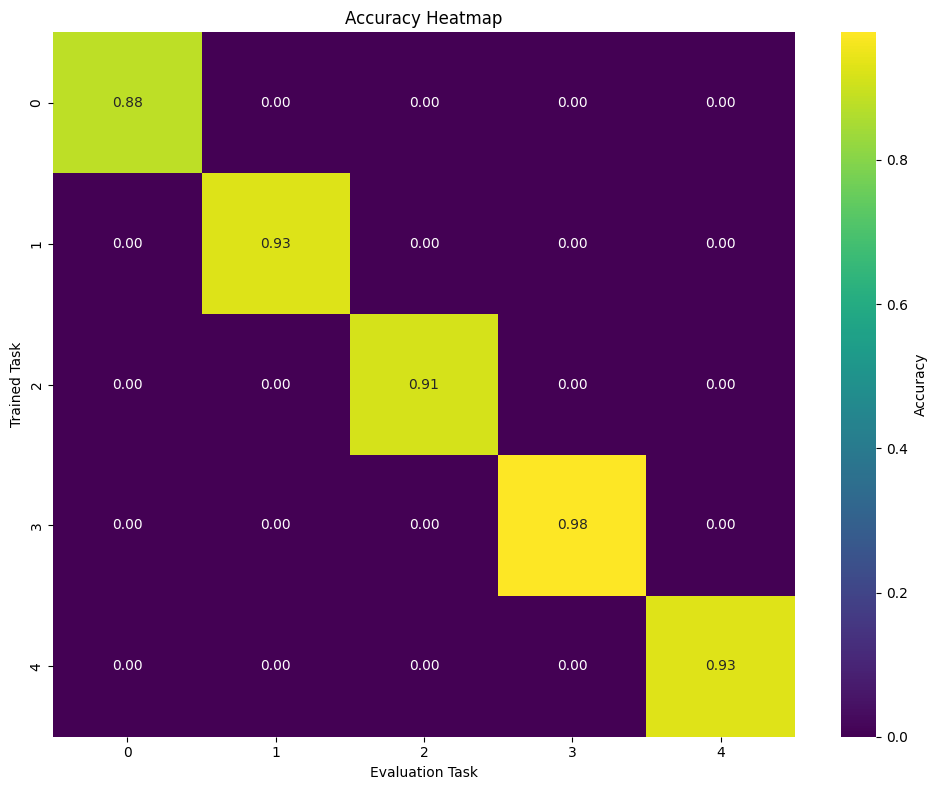


=== Strategy: RRR ===


/tmp/ipykernel_38117/294540121.py:6: FutureWarning: The provided callable <function mean at 0x7b144033df30> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = metric_df.pivot_table(


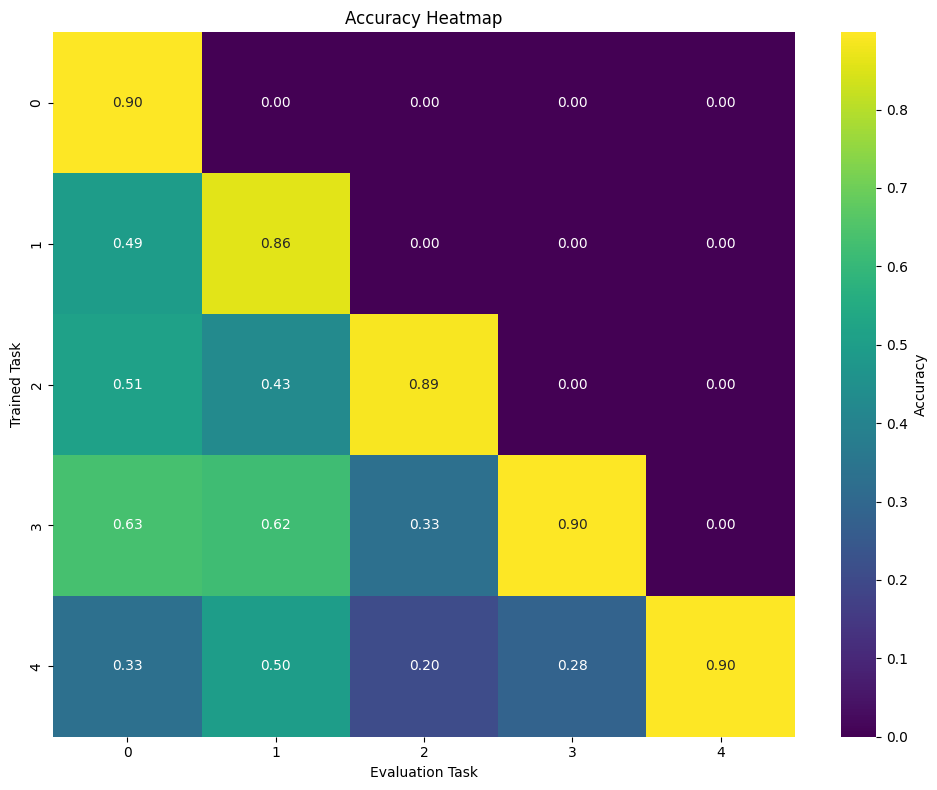

In [42]:
for strategy in df["strategy"].unique():
    strategy_df = df[df["strategy"] == strategy]
    print(f"\n=== Strategy: {strategy} ===")
    for metric in strategy_df["metric"].unique():
        metric_df = strategy_df[strategy_df["metric"] == metric]
        pivot_table = metric_df.pivot_table(
            index="trained_task", columns="eval_task", values="value", aggfunc=np.mean
        )

        # Plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            cbar_kws={"label": metric},
        )
        plt.title(f"{metric} Heatmap")
        plt.xlabel("Evaluation Task")
        plt.ylabel("Trained Task")
        plt.tight_layout()

        plt.show()